# Huygens’ dielectric surfaces: transmission, phase, and mesh study

A Beamz recreation of [Yankun (Alex) Meng’s Tidy3D community notebook](https://home.flexcompute.com/tidy3d/community/notebooks/Huygens/), following its simulation and plotting sequence. The design comes from Decker et al., *High-Efficiency Dielectric Huygens’ Surfaces* (2015), [DOI: 10.1002/adom.201400584](https://doi.org/10.1002/adom.201400584).

We retain the disk dimensions, constant material indices, wavelength range, two distinct background configurations, reference/device pairs, and short/long acquisition times. The transmission and phase panels correspond to different environments, as in the source notebook; they are not two observables of a single configuration.

The source notebook plots the square of a **power-flux ratio**. Here transmission is the flux ratio itself. Phase is obtained from the area-averaged complex transmitted field relative to the empty cell. Every curve below is a Beamz FDTD result; no source images or digitized curves are used.

## Imports and simulation overview

From the repository: `uv sync --extra dev`, then open this notebook with the resulting Python kernel. For GPU execution install a compatible JAX CUDA extra in that environment; CPU JAX also works. These examples use the single-device **JAX** backend, including on a GPU.

All lengths in code are in metres. The helper beside this notebook only draws geometry, runs simulations, and extracts DFT amplitudes. The physical setup and experiments are defined here. This notebook executes all seven lateral mesh resolutions; the finest cases take longer.

In [1]:
from pathlib import Path
import sys
import platform
import time

import jax
import matplotlib.pyplot as plt
import numpy as np
import beamz as bz
from beamz.design.raster import Scene, Object, Cylinder, Box

# Works when launched from either the repository or examples/notebooks.
REPO = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "examples/notebooks/_metasurface_utils.py").exists())
sys.path.insert(0, str(REPO / "examples/notebooks"))
from _metasurface_utils import (layered_axis, run_case, plane_amplitude,
                               release_device_memory, plot_setup, field_intensity)

plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.grid": True, "grid.alpha": .22,
                     "lines.linewidth": 1.8})
print(f"Python {platform.python_version()}; JAX {jax.__version__}; {jax.devices()}")

Python 3.11.15; JAX 0.10.2; [CudaDevice(id=0)]


## 0. Wavelength and frequency range

Match the source’s 301 frequency samples spanning 1.1–1.6 µm. Frequencies increase, so wavelengths decrease; the phase unwrap follows that same ordering.

In [2]:
um, nm = 1e-6, 1e-9
fmin, fmax = bz.LIGHT_SPEED / (1.6 * um), bz.LIGHT_SPEED / (1.1 * um)
freqs = np.linspace(fmin, fmax, 301)
freq0, bandwidth = .5 * (fmin + fmax), fmax - fmin
wavelengths_nm = bz.LIGHT_SPEED / freqs / nm
lambda0 = bz.LIGHT_SPEED / freq0
pulse = bz.GaussianPulse(freq0=freq0, fwidth=bandwidth / 2)

## 1–3. Domain, discretization, and materials

The silicon cylinder has radius 242 nm, height 220 nm, and period 666 nm. Silicon has constant index 3.5. The transmission case uses index 1.4 above the interface and 1.45 below; the phase case embeds the disk in index 1.66 polymer.

The lateral mesh is uniform with spacing `P / 32`. The vertical mesh resolves the shortest wavelength with at least 32 cells inside each medium, snaps the disk interfaces, and grows smoothly into the buffers. This is an explicit rectilinear counterpart to Tidy3D’s automatic vertical grid, rather than an identical meshing algorithm. Each reference uses exactly the same Yee grid as its device run. Native raster cylinders preserve the circular geometry.

In [3]:
P, h, radius = .666 * um, .220 * um, .242 * um
space = 2 * um
Lz = 2 * (space + h)
si = bz.Material(permittivity=3.5**2)
n_glass, n_oxide, n_polymer = 1.4, 1.45, 1.66
run_time_short, run_time_long = 50 / bandwidth, 200 / bandwidth
source_z = h + .5 * lambda0
transmission_z = -h - .5 * lambda0
reflection_z = 1.4 * um
pml_thickness = .4 * um


def huygens_grid(cells_per_period, background):
    n_background = n_glass if background == "glass" else n_polymer
    lateral = np.linspace(-P/2, P/2, cells_per_period + 1)
    shortest = bz.LIGHT_SPEED / fmax
    z = layered_axis(-Lz/2, Lz/2, [0, h],
                     shortest / (3.5 * 32), shortest / (n_background * 32))
    return bz.RectilinearGrid(lateral, lateral, z)


def huygens_scene(background, with_disk):
    upper_index = n_glass if background == "glass" else n_polymer
    lower_index = n_oxide if background == "glass" else n_polymer
    materials = (bz.Material(upper_index**2), bz.Material(lower_index**2), si)
    objects = [Object(Box((-P/2, -P/2, -Lz/2), (P/2, P/2, 0)), 1)]
    if with_disk:
        objects.append(Object(Cylinder((0, 0), radius, 0, h), 2, priority=1))
    return Scene(materials=materials, objects=tuple(objects))

## 4–7. Source, monitors, acquisition time, and boundaries

An x-polarized plane wave propagates in −z. Both lateral axes are periodic; the upper and lower z boundaries use CPML. The flux case records transmission and adds a backward monitor behind the source for an energy check. The phase case records `Ex` on the transmission plane. DFT sampling every 16 steps remains well above the optical Nyquist rate for these grids.

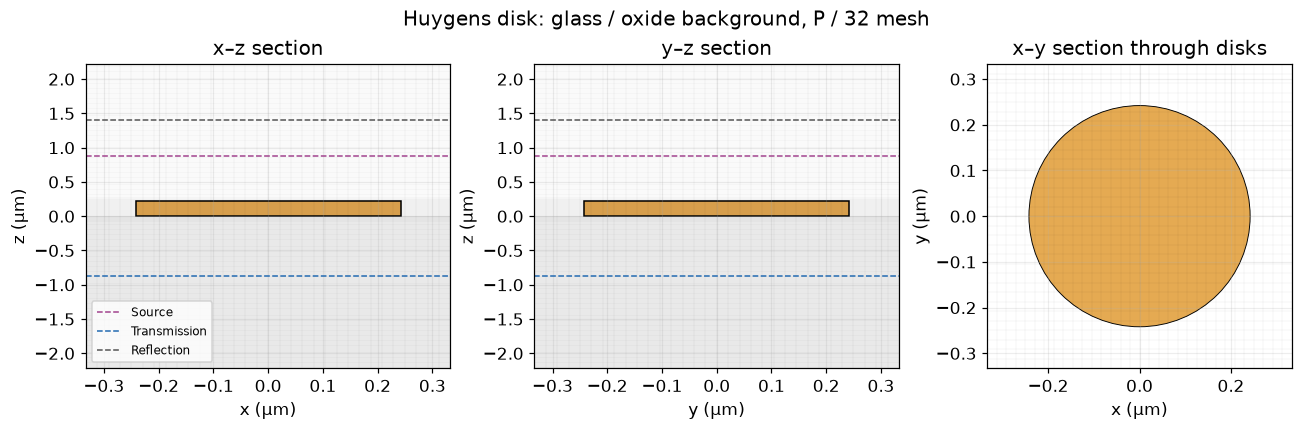

In [4]:
def simulation_helper(background, *, phase=False, with_disk=True, cells_per_period=32):
    grid = huygens_grid(cells_per_period, background)
    aperture = (P, P, 0)
    upper_index = n_glass if background == "glass" else n_polymer
    source = bz.PlaneWaveSource(
        center=(0, 0, source_z), size=aperture,
        source_time=pulse, direction="-z", pol_angle=0,
        background_index=upper_index)
    monitors = ([bz.FieldMonitor(center=(0, 0, transmission_z), size=aperture,
                                freqs=freqs, fields=("Ex",), interval=16, name="phase")]
                if phase else
                [bz.FluxMonitor(center=(0, 0, transmission_z), size=aperture,
                                freqs=freqs, interval=16, name="T"),
                 bz.FluxMonitor(center=(0, 0, reflection_z), size=aperture,
                                freqs=freqs, interval=16, name="R")])
    return bz.Simulation(
        scene=huygens_scene(background, with_disk), raster_grid=grid,
        run_time=run_time_long if phase else run_time_short,
        sources=[source], monitors=monitors,
        boundaries=[bz.Periodic(axes=("x", "y")),
                    bz.PML(edges=("front", "back"), thickness=pml_thickness,
                           formulation="cpml")])

plot_setup(huygens_grid(32, "glass"), radius=radius, height=h,
           layer_bottom=0, source_z=source_z, transmission_z=transmission_z,
           reflection_z=reflection_z,
           title="Huygens disk: glass / oxide background, P / 32 mesh")
plt.show()

## Transmittance simulation

Run the empty glass/oxide interface and the same cell with the silicon disk. Both transmission fluxes point in −z; their ratio is positive. Keep the reference Fresnel transmission separate when checking physical power conservation.

Glass / oxide reference: 9.5 s; 22,168 steps


Glass / oxide disk: 7.1 s; 22,168 steps


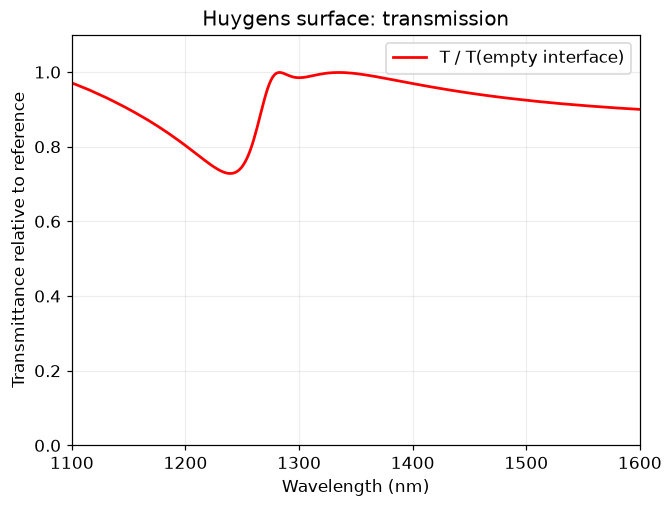

In [5]:
transmission_reference = run_case(simulation_helper("glass", with_disk=False),
                                  "Glass / oxide reference")
transmission_actual = run_case(simulation_helper("glass"), "Glass / oxide disk")
T = transmission_actual["T"].flux / transmission_reference["T"].flux
bare_interface_T = 4 * n_glass * n_oxide / (n_glass + n_oxide)**2
incident_power = -transmission_reference["T"].flux / bare_interface_T
R = transmission_actual["R"].flux / incident_power
T_physical = -transmission_actual["T"].flux / incident_power

fig, ax = plt.subplots(figsize=(6, 4.5), layout="constrained")
ax.plot(wavelengths_nm, T, color="red", label="T / T(empty interface)")
ax.set(xlabel="Wavelength (nm)", ylabel="Transmittance relative to reference",
       xlim=(1100, 1600), ylim=(0, 1.1), title="Huygens surface: transmission")
ax.legend()
plt.show()

## Phase simulation

Use the homogeneous polymer background for both the empty and disk runs, with the source’s longer `200 / bandwidth` acquisition. Plot the relative phase, the raw device phase, and the raw reference phase, following the source’s three-curve layout. Absolute phases include propagation and the pulse’s temporal phase.

Polymer reference: 18.2 s; 88,668 steps


Polymer disk: 15.9 s; 88,668 steps


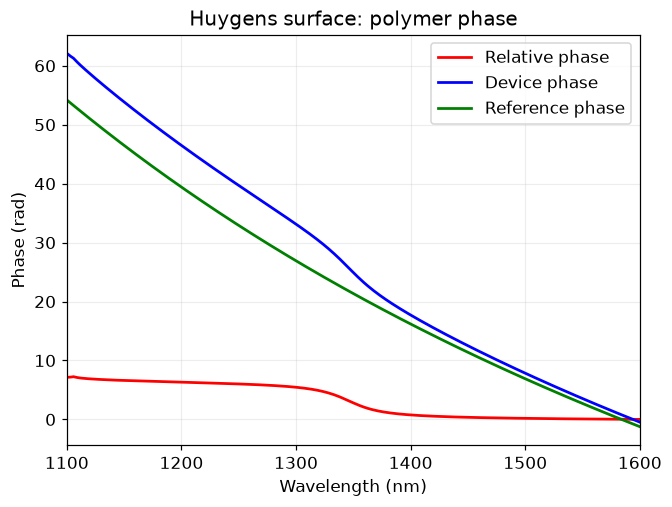

In [6]:
release_device_memory()
phase_reference = run_case(simulation_helper("polymer", phase=True, with_disk=False),
                          "Polymer reference")
phase_actual = run_case(simulation_helper("polymer", phase=True), "Polymer disk")
Ex_actual = plane_amplitude(phase_actual["phase"])
Ex_reference = plane_amplitude(phase_reference["phase"])
t_complex = Ex_actual / Ex_reference
phase_unwrapped = np.unwrap(np.angle(t_complex))
phase_relative = phase_unwrapped - phase_unwrapped[0]
phase_actual_unwrapped = np.unwrap(np.angle(Ex_actual))
phase_reference_unwrapped = np.unwrap(np.angle(Ex_reference))

fig, ax = plt.subplots(figsize=(6, 4.5), layout="constrained")
ax.plot(wavelengths_nm, phase_relative, "r", label="Relative phase")
ax.plot(wavelengths_nm, phase_actual_unwrapped, "b", label="Device phase")
ax.plot(wavelengths_nm, phase_reference_unwrapped, "g", label="Reference phase")
ax.set(xlabel="Wavelength (nm)", ylabel="Phase (rad)", xlim=(1100, 1600),
       title="Huygens surface: polymer phase")
ax.legend()
plt.show()

## Combined transmission and phase plots

Recreate the two-panel presentation and π-based phase ticks. Let the vertical limits include the measured curve rather than clipping it to an assumed 2π span.

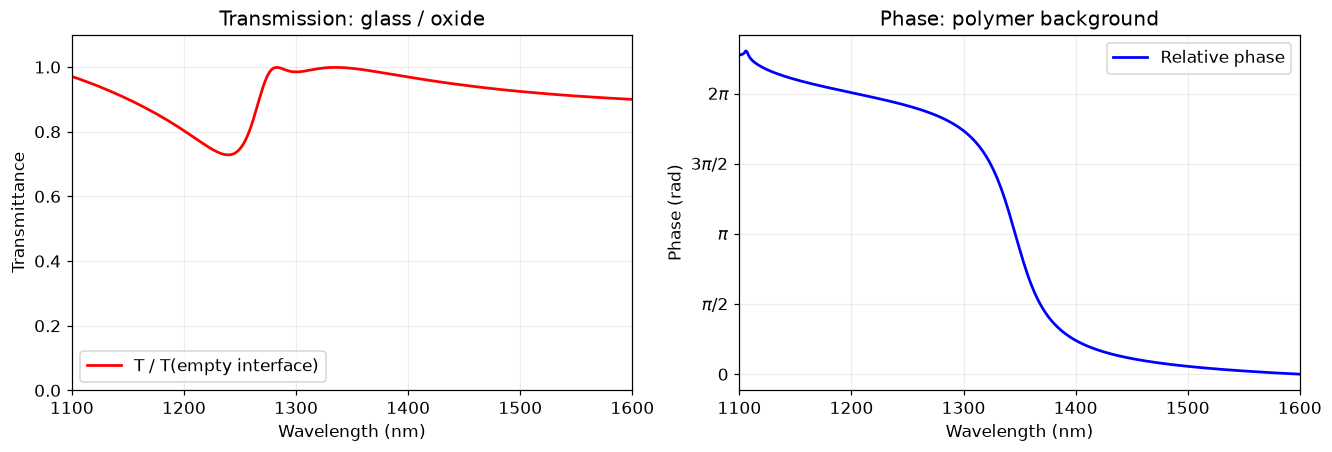

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
axes[0].plot(wavelengths_nm, T, "r", label="T / T(empty interface)")
axes[0].set(xlabel="Wavelength (nm)", ylabel="Transmittance", ylim=(0, 1.1),
            xlim=(1100, 1600), title="Transmission: glass / oxide")
axes[1].plot(wavelengths_nm, phase_relative, "b", label="Relative phase")
axes[1].set(xlabel="Wavelength (nm)", ylabel="Phase (rad)", xlim=(1100, 1600),
            title="Phase: polymer background")
axes[1].set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
                   ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
for ax in axes:
    ax.legend()
plt.show()

## Mesh study

Retain all seven lateral spacings: P/2, P/4, P/8, P/16, P/32, P/64, and P/128. The vertical mesh stays fixed. The source and monitor positions also stay fixed, avoiding the source notebook’s additional position changes during its mesh study. The coarsest meshes intentionally underresolve the disk.

P / 2 reference: 4.6 s; 18,602 steps


P / 2 disk: 2.3 s; 18,602 steps


P / 4 reference: 4.7 s; 18,648 steps


P / 4 disk: 2.4 s; 18,648 steps


P / 8 reference: 4.8 s; 18,831 steps


...

P / 16 disk: 3.5 s; 19,544 steps


P / 64 reference: 30.7 s; 30,483 steps


P / 64 disk: 28.2 s; 30,483 steps


P / 128 reference: 275.0 s; 51,772 steps


P / 128 disk: 315.0 s; 51,772 steps


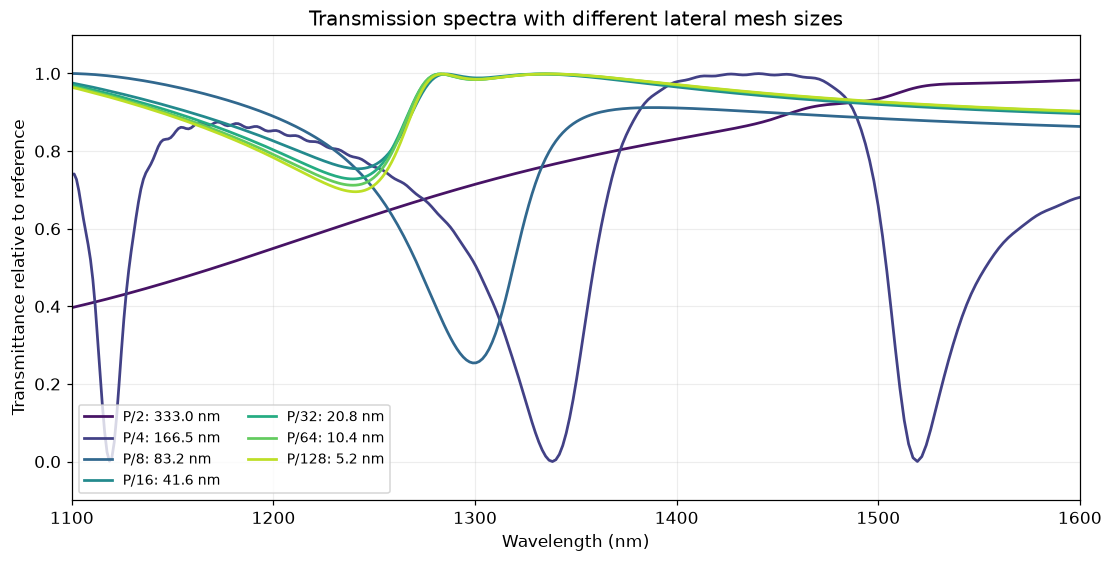

In [8]:
mesh_counts = [2, 4, 8, 16, 32, 64, 128]
mesh_spectra = {}
for count in mesh_counts:
    if count == 32:
        mesh_spectra[count] = T.copy()
        continue
    release_device_memory()
    empty = run_case(simulation_helper("glass", with_disk=False, cells_per_period=count),
                     f"P / {count} reference")
    actual = run_case(simulation_helper("glass", cells_per_period=count),
                      f"P / {count} disk")
    mesh_spectra[count] = actual["T"].flux / empty["T"].flux
    del empty, actual

fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
colors = plt.colormaps["viridis"](np.linspace(.05, .9, len(mesh_counts)))
for count, color in zip(mesh_counts, colors, strict=True):
    ax.plot(wavelengths_nm, mesh_spectra[count], color=color,
            label=f"P/{count}: {P/count/nm:.1f} nm")
ax.set(xlabel="Wavelength (nm)", ylabel="Transmittance relative to reference",
       xlim=(1100, 1600), ylim=(-.1, 1.1),
       title="Transmission spectra with different lateral mesh sizes")
ax.legend(ncol=2, fontsize=9)
plt.show()

## Checks and reproducible results

Lossless physical power should approximately satisfy R + T = 1. The reference-normalized transmission differs slightly from physical transmission because the bare glass/oxide interface reflects a small amount. Report mesh changes rather than assuming the last mesh is converged.

In [9]:
energy_error = np.max(np.abs(R + T_physical - 1))
last_mesh_change = np.max(np.abs(mesh_spectra[128] - mesh_spectra[64]))
assert np.isfinite(T).all() and np.isfinite(t_complex).all()
assert np.min(T) > -.02 and np.max(T) < 1.05
assert energy_error < .05, f"Lossless power residual: {energy_error:.3g}"
print(f"Maximum |R + T - 1|: {energy_error:.4f}")
print(f"Maximum P/64 → P/128 transmission change: {last_mesh_change:.4f}")
print(f"Relative phase span: {np.ptp(phase_relative):.3f} rad")
output = REPO / "examples/results/huygens_surface.npz"
output.parent.mkdir(exist_ok=True)
np.savez_compressed(output, frequency_hz=freqs, wavelength_nm=wavelengths_nm,
                    transmission_relative=T, transmission_physical=T_physical,
                    reflection=R, transmission_complex=t_complex,
                    phase_relative_rad=phase_relative, mesh_counts=mesh_counts,
                    mesh_transmission=np.stack([mesh_spectra[n] for n in mesh_counts]))
print(f"Saved {output.relative_to(REPO)}")

Maximum |R + T - 1|: 0.0002
Maximum P/64 → P/128 transmission change: 0.0226
Relative phase span: 7.242 rad
Saved examples/results/huygens_surface.npz


## Interpretation

Compare the resonance features and phase variation with the linked Tidy3D notebook, accounting for the corrected power normalization and a different subpixel/vertical-mesh implementation. The mesh sweep quantifies only lateral discretization; vertical spacing, CPML thickness, and acquisition time also affect agreement. These runs use zero-phase periodic boundaries at normal incidence, which is the Bloch zero-wavevector limit.

The saved run has a maximum lossless power residual of approximately 0.0002 and a maximum P/64 → P/128 transmission change of 0.0226. Its polymer phase span is about 7.24 rad, including a small feature at the short-wavelength end; this is not an exact 2π phase-span match. The combined plot preserves this feature rather than clipping it to the source figure’s 2π axis limit.